### Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Load the transactions.csv dataset into a Pandas DataFrame

In [3]:
df = pd.read_csv('Transactions (1).csv')
df

,Transaction_ID,Product,Category,Quantity,Unit_Price,Date,Store
0,1,Charger,Gadgets,4,956.903512,2022-06-01,Store_A
1,2,Laptop,Electronics,5,303.653831,2022-04-04,Store_B
2,3,Tablet,Gadgets,8,226.925798,2022-08-10,Store_A
3,4,Laptop,Electronics,4,975.494448,2022-04-22,Store_C
4,5,Mobile,Gadgets,8,656.776002,2022-03-05,Store_A
...,...,...,...,...,...,...,...
1995,1996,Laptop,Gadgets,3,233.877464,2022-06-10,Store_A
1996,1997,Laptop,Accessories,9,228.565391,2022-05-02,Store_A
1997,1998,Charger,Gadgets,2,580.724017,2022-02-11,Store_B
1998,1999,Laptop,Accessories,7,986.839054,2022-08-26,Store_A


### Calculate revenue for each transaction by multiplying quantity and unit price

In [4]:
df['revenue'] = df['Quantity']*df['Unit_Price']
df

,Transaction_ID,Product,Category,Quantity,Unit_Price,Date,Store,revenue
0,1,Charger,Gadgets,4,956.903512,2022-06-01,Store_A,3827.614047
1,2,Laptop,Electronics,5,303.653831,2022-04-04,Store_B,1518.269156
2,3,Tablet,Gadgets,8,226.925798,2022-08-10,Store_A,1815.406386
3,4,Laptop,Electronics,4,975.494448,2022-04-22,Store_C,3901.977794
4,5,Mobile,Gadgets,8,656.776002,2022-03-05,Store_A,5254.208013
...,...,...,...,...,...,...,...,...
1995,1996,Laptop,Gadgets,3,233.877464,2022-06-10,Store_A,701.632392
1996,1997,Laptop,Accessories,9,228.565391,2022-05-02,Store_A,2057.088521
1997,1998,Charger,Gadgets,2,580.724017,2022-02-11,Store_B,1161.448034
1998,1999,Laptop,Accessories,7,986.839054,2022-08-26,Store_A,6907.873380


### Convert the date column to a date time format

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format= '%Y-%m-%d')
print(df['Date'].dtype)

datetime64[ns]


### Plot the distribituon of total revenue across different stores using a bar plot

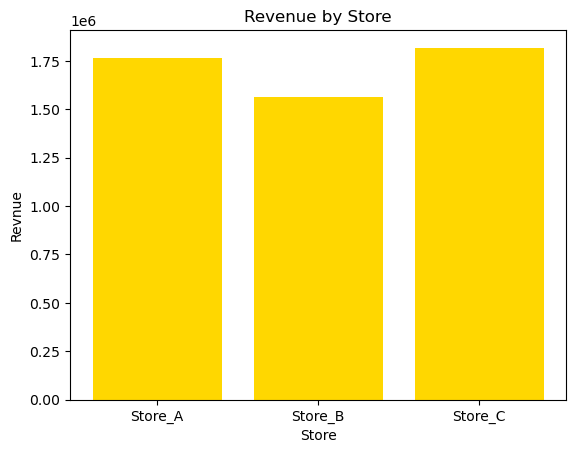

In [17]:
store = df.groupby(['Store']).agg(revenue = ('revenue','sum')).reset_index()
plt.bar(store['Store'],store['revenue'], color='gold')
plt.title('Revenue by Store')
plt.xlabel('Store')
plt.ylabel('Revnue')
plt.show()

### Extract the month from the date column

In [18]:
df['Month'] = df['Date'].dt.month
df

,Transaction_ID,Product,Category,Quantity,Unit_Price,Date,Store,revenue,Month
0,1,Charger,Gadgets,4,956.903512,2022-06-01,Store_A,3827.614047,6
1,2,Laptop,Electronics,5,303.653831,2022-04-04,Store_B,1518.269156,4
2,3,Tablet,Gadgets,8,226.925798,2022-08-10,Store_A,1815.406386,8
3,4,Laptop,Electronics,4,975.494448,2022-04-22,Store_C,3901.977794,4
4,5,Mobile,Gadgets,8,656.776002,2022-03-05,Store_A,5254.208013,3
...,...,...,...,...,...,...,...,...,...
1995,1996,Laptop,Gadgets,3,233.877464,2022-06-10,Store_A,701.632392,6
1996,1997,Laptop,Accessories,9,228.565391,2022-05-02,Store_A,2057.088521,5
1997,1998,Charger,Gadgets,2,580.724017,2022-02-11,Store_B,1161.448034,2
1998,1999,Laptop,Accessories,7,986.839054,2022-08-26,Store_A,6907.873380,8


### Group the data by month and calculate the total revenue for each month

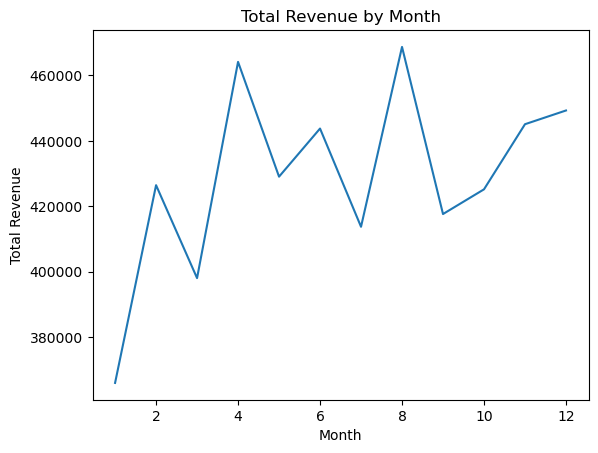

In [35]:
#Plot the montly revenue
dfmonth = df.groupby(['Month']).agg(Total_Revenue = ('revenue','sum')).reset_index()
sns.lineplot(data=dfmonth, x='Month', y='Total_Revenue')
plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.show()

### Analyze Sales Volume by products

In [28]:
#Group the data by product and calculate total quantity sold for each product and identify top 5
top_prod = df.groupby(['Product']).agg(Total_Quantity= ('Quantity','sum')).sort_values(by= 'Total_Quantity', ascending= False).reset_index()
top_prod

,Product,Total_Quantity
0,Mobile,2211
1,Laptop,2129
2,Charger,2062
3,Headphones,1924
4,Tablet,1874


C:\Users\kevin\AppData\Local\Temp\ipykernel_48252\3654005597.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




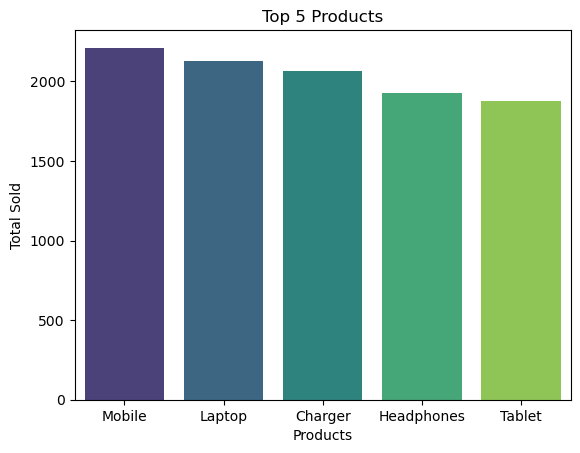

In [29]:
#Plot the top 5 products using a bar plot
sns.barplot(data=top_prod, x='Product',y='Total_Quantity', palette='viridis')
plt.title('Top 5 Products')
plt.xlabel('Products')
plt.ylabel('Total Sold')
plt.show()

### Analyze Quantity sold by Product Category

In [30]:
#Group the data by product category and calculate the total quantity sold for each catgerory
cat = df.groupby(['Category']).agg(Total_sold=('Quantity','sum')).reset_index()
cat

,Category,Total_sold
0,Accessories,3505
1,Electronics,3411
2,Gadgets,3284


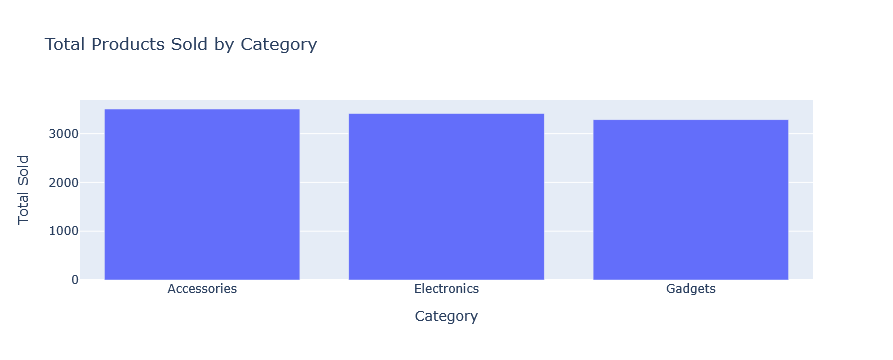

In [36]:
#Plot the total quantity sold per category using Plotly express
fig = px.bar(cat, x='Category', y='Total_sold',
             title= 'Total Products Sold by Category',
             labels={'Category':'Category','Total_sold':'Total Sold'})
fig.show()

### Analyze Store Revenue and Product Data

In [38]:
#Create a pivot table to show montly revenue for each store
pivot= pd.pivot_table(df, values='revenue', index='Month', columns='Store', aggfunc='sum').reset_index()
pivot

Store,Month,Store_A,Store_B,Store_C
0,1,155844.177361,100283.584550,109859.048362
1,2,156625.914028,113986.074279,155840.473281
2,3,80540.518435,150940.806224,166554.812633
3,4,138393.315190,151849.663380,173914.242999
4,5,160807.271068,151298.035767,116951.459379
5,6,160766.094426,105211.656341,177793.372868
6,7,139729.307324,139308.339530,134695.907964
7,8,170930.819935,146628.049065,151172.156017
8,9,138720.309507,138825.608439,140084.778161
9,10,173776.625893,117974.432364,133433.540899


In [39]:
df

,Transaction_ID,Product,Category,Quantity,Unit_Price,Date,Store,revenue,Month
0,1,Charger,Gadgets,4,956.903512,2022-06-01,Store_A,3827.614047,6
1,2,Laptop,Electronics,5,303.653831,2022-04-04,Store_B,1518.269156,4
2,3,Tablet,Gadgets,8,226.925798,2022-08-10,Store_A,1815.406386,8
3,4,Laptop,Electronics,4,975.494448,2022-04-22,Store_C,3901.977794,4
4,5,Mobile,Gadgets,8,656.776002,2022-03-05,Store_A,5254.208013,3
...,...,...,...,...,...,...,...,...,...
1995,1996,Laptop,Gadgets,3,233.877464,2022-06-10,Store_A,701.632392,6
1996,1997,Laptop,Accessories,9,228.565391,2022-05-02,Store_A,2057.088521,5
1997,1998,Charger,Gadgets,2,580.724017,2022-02-11,Store_B,1161.448034,2
1998,1999,Laptop,Accessories,7,986.839054,2022-08-26,Store_A,6907.873380,8


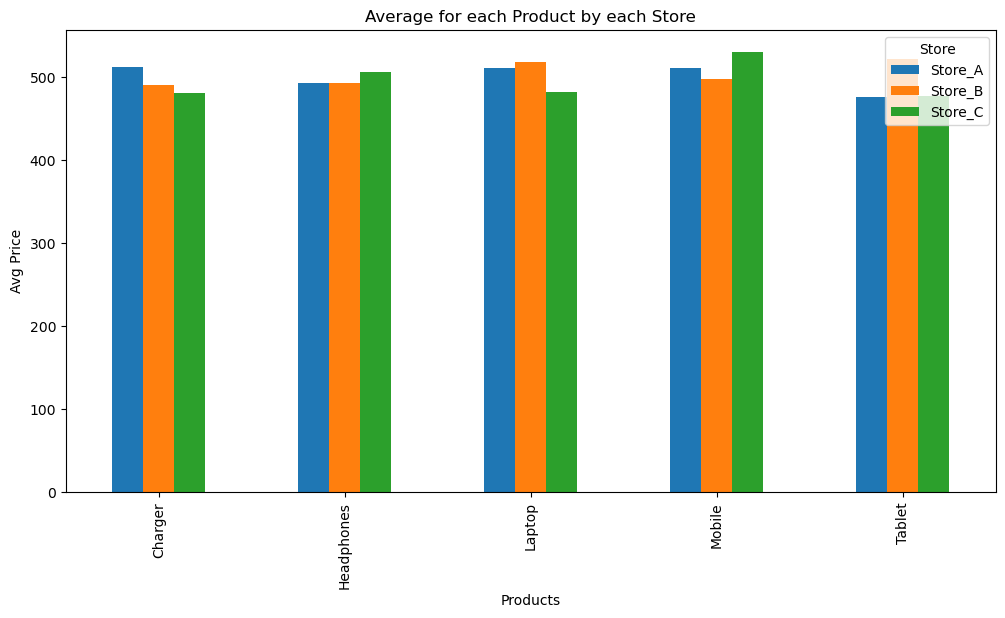

In [45]:
#Plot the average unit price for each store using a bar plot
pivot2 = pd.pivot_table(df, values='Unit_Price', index= 'Product', columns= 'Store', aggfunc='mean').reset_index()
pivot2.plot(kind='bar', x='Product', figsize=(12,6))
plt.title('Average for each Product by each Store')
plt.xlabel('Products')
plt.ylabel('Avg Price')
plt.show()


C:\Users\kevin\AppData\Local\Temp\ipykernel_48252\310772238.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




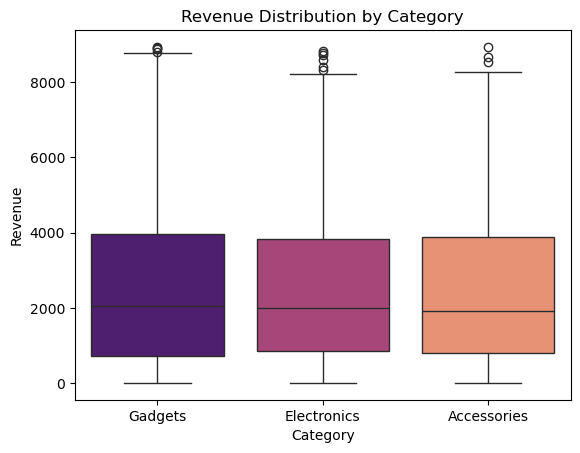

In [49]:
#Plot the revenue distribution for each category using a boxplot
sns.boxplot(data=df, x='Category',y='revenue', palette='magma')
plt.title('Revenue Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.show()

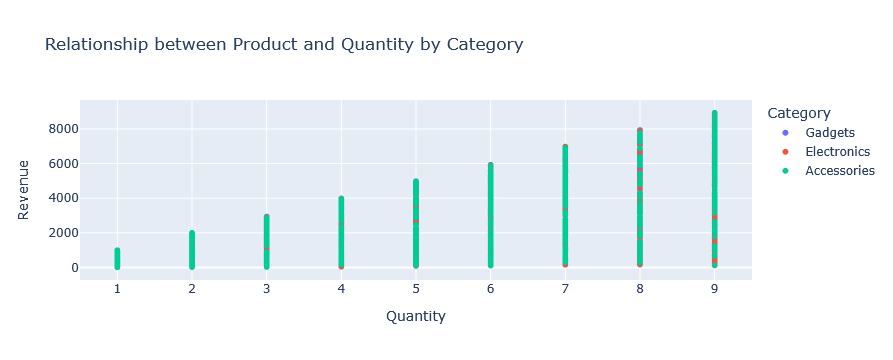

In [56]:
#Plot a scatter plot to show the relationship between quantity and revenue across different catgeories using Plotly
fig= px.scatter(df, x='Quantity',y='revenue', color='Category',
                title= 'Relationship between Product and Quantity by Category',
                labels={'Quantity':'Quantity','revenue':'Revenue'})
fig.show()